> Segmentaion 

In [1]:
# ==============================================================
# 1. Imports
# ==============================================================
import numpy as np
import pandas as pd
import os
import cv2
import random
from tqdm import tqdm
from tensorflow.keras.utils import load_img
from tensorflow.image import resize
import matplotlib.pyplot as plt

2025-11-25 15:11:26.744259: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764083486.910090      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764083486.959188      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# ==============================================================
# 2. Fix seed
# ==============================================================
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)

In [3]:
# ==============================================================
# 3. Load dataset paths
# ==============================================================
data_dir = "/kaggle/input/blood-cell-cancer-all-4class/Blood cell Cancer [ALL]"

imgs_path = []
classes = []

for dirpath, dirnames, filenames in os.walk(data_dir):
    if len(classes) == 0:
        classes = dirnames  # save the class folder names
    for filename in filenames:
        imgs_path.append(os.path.join(dirpath, filename))

In [4]:
# ==============================================================
# 4. Build dataframe
# ==============================================================
def get_class(x):
    for c in classes:
        if c in x:
            return c

df = pd.DataFrame({"filepath": imgs_path})
df["class"] = df["filepath"].apply(get_class)

df.head()

,filepath,class
0,/kaggle/input/blood-cell-cancer-all-4class/Blo...,[Malignant] early Pre-B
1,/kaggle/input/blood-cell-cancer-all-4class/Blo...,[Malignant] early Pre-B
2,/kaggle/input/blood-cell-cancer-all-4class/Blo...,[Malignant] early Pre-B
3,/kaggle/input/blood-cell-cancer-all-4class/Blo...,[Malignant] early Pre-B
4,/kaggle/input/blood-cell-cancer-all-4class/Blo...,[Malignant] early Pre-B


In [5]:
# ==============================================================
# 5. Helper functions for segmentation
# ==============================================================
def get_image(pathfile):
    return cv2.cvtColor(cv2.imread(pathfile), cv2.COLOR_BGR2RGB)

def RGB2LAB(image):
    image_lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(image_lab)
    return l, a, b

def get_mask(image):
    l, a, b = RGB2LAB(image)
    a_blur = cv2.GaussianBlur(a, (19, 19), 0)
    _, thresh = cv2.threshold(a_blur, 200, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((2, 2), np.uint8)
    mask = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=1)
    return mask

def apply_mask(image, mask):
    return cv2.bitwise_and(image, image, mask=mask)

I0000 00:00:1764083513.602210      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


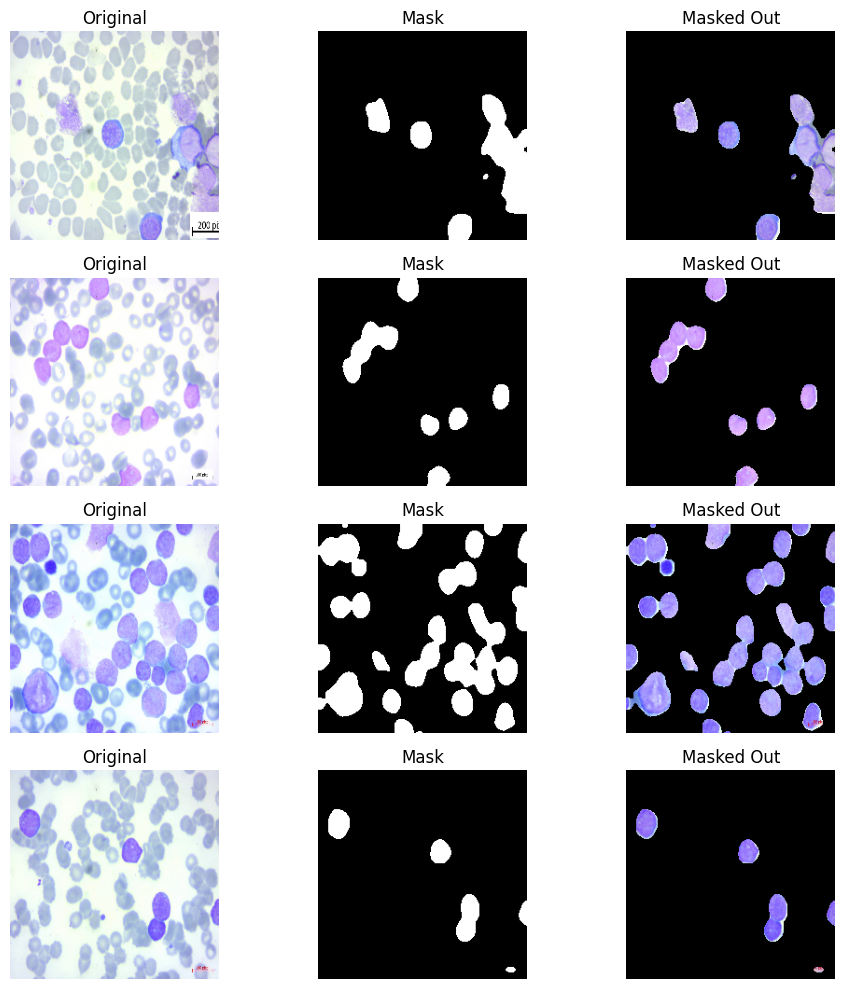

In [6]:
# ==============================================================
# 6. Show some sample original + mask + masked out
# ==============================================================
img_shape = (224, 224)
sample = df.sample(4)

plt.figure(figsize=(10, 10))
for i, row in enumerate(sample.iterrows()):
    image = get_image(row[1].filepath)
    image = resize(image, img_shape).numpy().astype("uint8")
    mask = get_mask(image)
    masked_img = apply_mask(image, mask)

    plt.subplot(4, 3, i*3 + 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(4, 3, i*3 + 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(4, 3, i*3 + 3)
    plt.imshow(masked_img)
    plt.title("Masked Out")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# ==============================================================
# 7. Create output dataset folder structure
# ==============================================================

OUTPUT_DATASET = "/kaggle/working/Segmented_Dataset"

MASK_FOLDER = os.path.join(OUTPUT_DATASET, "Masks")
MASKEDOUT_FOLDER = os.path.join(OUTPUT_DATASET, "Masked_Images")

os.makedirs(MASK_FOLDER, exist_ok=True)
os.makedirs(MASKEDOUT_FOLDER, exist_ok=True)

for c in classes:
    os.makedirs(os.path.join(MASK_FOLDER, c), exist_ok=True)
    os.makedirs(os.path.join(MASKEDOUT_FOLDER, c), exist_ok=True)

print("Folder structure created successfully!")

Folder structure created successfully!


In [8]:
# ==============================================================
# 8. Function to generate entire dataset (mask + masked image)
# ==============================================================
def create_segmented_dataset(df):
    print("Processing dataset...\n")

    for idx, row in tqdm(df.iterrows(), total=len(df)):

        class_name = row["class"]
        filepath = row["filepath"]

        # Load & resize
        image = get_image(filepath)
        image = resize(image, img_shape).numpy().astype("uint8")

        # Generate mask & masked image
        mask = get_mask(image)
        masked_img = apply_mask(image, mask)

        # Save mask
        save_mask_path = os.path.join(MASK_FOLDER, class_name, os.path.basename(filepath))
        cv2.imwrite(save_mask_path, mask)

        # Save masked image
        save_masked_path = os.path.join(MASKEDOUT_FOLDER, class_name, os.path.basename(filepath))
        cv2.imwrite(save_masked_path, cv2.cvtColor(masked_img, cv2.COLOR_RGB2BGR))

    print("\nDataset creation completed!")

In [9]:
# ==============================================================
# 9. Run the segmentation + save dataset
# ==============================================================
create_segmented_dataset(df)

print("\nAll masks and masked images saved successfully!")
print("Location:", OUTPUT_DATASET)

Processing dataset...



100%|██████████| 3242/3242 [01:18<00:00, 41.21it/s]


Dataset creation completed!

All masks and masked images saved successfully!
Location: /kaggle/working/Segmented_Dataset


> H Separation

> E Separation

> H & E Normalization

In [10]:
import numpy as np
import cv2
import os
"""
            Input: RGB image
            Step 1: Convert RGB to OD
            Step 2: Remove data with OD intensity less than β
            Step 3: Calculate  singular value decomposition (SVD) on the OD tuples
            Step 4: Create plane from the SVD directions corresponding to the
            two largest singular values
            Step 5: Project data onto the plane, and normalize to unit length
            Step 6: Calculate angle of each point wrt the first SVD direction
            Step 7: Find robust extremes (αth and (100−α)th 7 percentiles) of the
            angle
            Step 8: Convert extreme values back to OD space

            Output: Optimal Stain Vectors

"""

def normalize_he_images(input_dir, output_dir, Io=240, alpha=1, beta=0.15, resize_to = None):
    # Create output directories
    os.makedirs(output_dir, exist_ok=True)
    h_folder = os.path.join(output_dir, "H-stains")
    e_folder = os.path.join(output_dir, "E-stains")
    os.makedirs(h_folder, exist_ok=True)
    os.makedirs(e_folder, exist_ok=True)

    for filename in tqdm(os.listdir(input_dir), desc="Processing files"):
        if filename.endswith((".jpg", ".png", ".tif", ".bmp")):
            img_path = os.path.join(input_dir, filename)
            ############### INPUT RGB IMAGE #######################
            #Using opencv to read images may bemore robust compared to using skimage
            #but need to remember to convert BGR to RGB.
            #Also, convert to float later on and normalize to between 0 and 1.
            try: 
                img=cv2.imread(img_path, 1)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                #Io = 240 # Transmitted light intensity, Normalizing factor for image intensities
                #alpha = 1  #As recommend in the paper. tolerance for the pseudo-min and pseudo-max (default: 1)
                #beta = 0.15 #As recommended in the paper. OD threshold for transparent pixels (default: 0.15)


                ######## Step 1: Convert RGB to OD ###################
                ## reference H&E OD matrix.
                #Can be updated if you know the best values for your image. 
                #Otherwise use the following default values. 
                #Read the above referenced papers on this topic. 
                HERef = np.array([[0.5626, 0.2159],
                                [0.7201, 0.8012],
                                [0.4062, 0.5581]])
                ### reference maximum stain concentrations for H&E
                maxCRef = np.array([1.9705, 1.0308])


                # extract the height, width and num of channels of image
                h, w, c = img.shape

                # reshape image to multiple rows and 3 columns.
                #Num of rows depends on the image size (wxh)
                img = img.reshape((-1,3))

                # calculate optical density
                # OD = −log10(I)  
                #OD = -np.log10(img+0.004)  #Use this when reading images with skimage
                #Adding 0.004 just to avoid log of zero. 

                OD = -np.log10((img.astype(np.float64)+1)/Io) #Use this for opencv imread
                #Add 1 in case any pixels in the image have a value of 0 (log 0 is indeterminate)

                """
                from mpl_toolkits.mplot3d import Axes3D

                fig = plt.figure(figsize=(16, 8))
                ax1 = fig.add_subplot(121, projection='3d')
                ax1.scatter(img[:,0],img[:,1],img[:,2])
                ax2 = fig.add_subplot(122, projection='3d')
                ax2.scatter(OD[:,0],OD[:,1],OD[:,2])

                plt.show()
                """

                ############ Step 2: Remove data with OD intensity less than β ############
                # remove transparent pixels (clear region with no tissue)
                ODhat = OD[~np.any(OD < beta, axis=1)] #Returns an array where OD values are above beta
                #Check by printing ODhat.min()

                ############# Step 3: Calculate SVD on the OD tuples ######################
                #Estimate covariance matrix of ODhat (transposed)
                # and then compute eigen values & eigenvectors.
                eigvals, eigvecs = np.linalg.eigh(np.cov(ODhat.T))


                ######## Step 4: Create plane from the SVD directions with two largest values ######
                #project on the plane spanned by the eigenvectors corresponding to the two 
                # largest eigenvalues    
                That = ODhat.dot(eigvecs[:,1:3]) #Dot product

                ############### Step 5: Project data onto the plane, and normalize to unit length ###########
                ############## Step 6: Calculate angle of each point wrt the first SVD direction ########
                #find the min and max vectors and project back to OD space
                phi = np.arctan2(That[:,1],That[:,0])

                minPhi = np.percentile(phi, alpha)
                maxPhi = np.percentile(phi, 100-alpha)

                vMin = eigvecs[:,1:3].dot(np.array([(np.cos(minPhi), np.sin(minPhi))]).T)
                vMax = eigvecs[:,1:3].dot(np.array([(np.cos(maxPhi), np.sin(maxPhi))]).T)


                # a heuristic to make the vector corresponding to hematoxylin first and the 
                # one corresponding to eosin second
                if vMin[0] > vMax[0]:    
                    HE = np.array((vMin[:,0], vMax[:,0])).T
                    
                else:
                    HE = np.array((vMax[:,0], vMin[:,0])).T


                # rows correspond to channels (RGB), columns to OD values
                Y = np.reshape(OD, (-1, 3)).T

                # determine concentrations of the individual stains
                C = np.linalg.lstsq(HE,Y, rcond=None)[0]

                # normalize stain concentrations
                maxC = np.array([np.percentile(C[0,:], 99), np.percentile(C[1,:],99)])
                tmp = np.divide(maxC,maxCRef)
                C2 = np.divide(C,tmp[:, np.newaxis])

                ###### Step 8: Convert extreme values back to OD space
                # recreate the normalized image using reference mixing matrix 

                #soltion for overflow by faysal
                exponent_values = -HERef.dot(C2)
                exponent_values = np.clip(exponent_values, -100, 100)  # Prevent extreme values
                Inorm = np.multiply(Io, np.exp(exponent_values))  

                #Inorm = np.multiply(Io, np.exp(-HERef.dot(C2))) #original code but exceed floating limit
                Inorm[Inorm>255] = 254
                Inorm = np.reshape(Inorm.T, (h, w, 3)).astype(np.uint8)  
                
                #clipping extreme value for H also
                H_exp = np.expand_dims(-HERef[:, 0], axis=1).dot(np.expand_dims(C2[0, :], axis=0))
                H_exp = np.clip(H_exp, -100, 100)  # Clip exponent values to avoid overflow
                H = np.multiply(Io, np.exp(H_exp))
                #H = np.multiply(Io, np.exp(np.expand_dims(-HERef[:,0], axis=1).dot(np.expand_dims(C2[0,:], axis=0))))
                H[H>255] = 254
                H = np.reshape(H.T, (h, w, 3)).astype(np.uint8)

                # For E calculation
                E_exp = np.expand_dims(-HERef[:, 1], axis=1).dot(np.expand_dims(C2[1, :], axis=0))
                E_exp = np.clip(E_exp, -100, 100)  # Clip exponent values to avoid overflow
                E = np.multiply(Io, np.exp(E_exp))
                #E = np.multiply(Io, np.exp(np.expand_dims(-HERef[:,1], axis=1).dot(np.expand_dims(C2[1,:], axis=0))))
                E[E>255] = 254
                E = np.reshape(E.T, (h, w, 3)).astype(np.uint8)

                # Resize images to 224x224
                if resize_to is not None:
                    Inorm = cv2.resize(Inorm, resize_to, interpolation=cv2.INTER_AREA)
                    H = cv2.resize(H, resize_to, interpolation=cv2.INTER_AREA)
                    E = cv2.resize(E, resize_to, interpolation=cv2.INTER_AREA)
                
                # Save the images
                base_filename = os.path.splitext(filename)[0]
                cv2.imwrite(os.path.join(output_dir, f"{base_filename}_normalized.jpg"), cv2.cvtColor(Inorm, cv2.COLOR_RGB2BGR))
                cv2.imwrite(os.path.join(h_folder, f"{base_filename}_H.jpg"), cv2.cvtColor(H, cv2.COLOR_RGB2BGR))
                cv2.imwrite(os.path.join(e_folder, f"{base_filename}_E.jpg"), cv2.cvtColor(E, cv2.COLOR_RGB2BGR))
                
                #print(f"Processed: {filename}")
            except Exception as e:
                # If an error occurs, save the original image and print the filename
                print(f"Skipping {filename} due to error: {e}")
                cv2.imwrite(os.path.join(output_dir, filename), cv2.imread(img_path))


In [11]:
# -------------------------
# MAIN DATASET DIRECTORY
# -------------------------
data_dir = "/kaggle/input/blood-cell-cancer-all-4class/Blood cell Cancer [ALL]"

# -------------------------
# OUTPUT DIRECTORY
# -------------------------
output_root = "/kaggle/working/HE_Normalized_Dataset"
os.makedirs(output_root, exist_ok=True)

# -------------------------
# LOOP THROUGH CLASS FOLDERS
# -------------------------
for class_name in os.listdir(data_dir):

    class_path = os.path.join(data_dir, class_name)

    # Ignore non-directory files
    if not os.path.isdir(class_path):
        continue

    print(f"\n===============================")
    print(f" Processing Class: {class_name}")
    print(f"===============================\n")

    # Create output directory for this class
    out_dir = os.path.join(output_root, class_name)
    os.makedirs(out_dir, exist_ok=True)

    # Call your normalization function
    normalize_he_images(
        input_dir=class_path,
        output_dir=out_dir,
        Io=240,
        alpha=1,
        beta=0.15, 
        resize_to = (224, 224)
    )

print("\n\n🎉 DONE! All classes processed successfully.")
print(f"Normalized dataset saved to: {output_root}")


 Processing Class: [Malignant] early Pre-B



Processing files: 100%|██████████| 979/979 [03:40<00:00,  4.43it/s]



 Processing Class: [Malignant] Pro-B



Processing files: 100%|██████████| 796/796 [03:06<00:00,  4.26it/s]



 Processing Class: [Malignant] Pre-B



Processing files: 100%|██████████| 955/955 [03:30<00:00,  4.53it/s]



 Processing Class: Benign



Processing files: 100%|██████████| 512/512 [02:51<00:00,  2.98it/s]



🎉 DONE! All classes processed successfully.
Normalized dataset saved to: /kaggle/working/HE_Normalized_Dataset


In [12]:
import os
import zipfile
from tqdm import tqdm

source_dir = "/kaggle/working"
zip_path = "/kaggle/working/working_directory.zip"

# Remove existing ZIP if any
if os.path.exists(zip_path):
    os.remove(zip_path)

# Collect all files in directory
all_files = []
for root, dirs, files in os.walk(source_dir):
    for file in files:
        all_files.append(os.path.join(root, file))

print(f"Zipping {len(all_files)} files...")

# Create ZIP with progress bar
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in tqdm(all_files, desc="Zipping files"):
        # Keep relative path in zip
        rel_path = os.path.relpath(file, source_dir)
        zipf.write(file, rel_path)

print("Zipping complete!")

# Show final file size
size = os.path.getsize(zip_path) / (1024*1024)
print(f"Final ZIP size: {size:.2f} MB")
print(f"\nDownload link: {zip_path}")

Zipping 16210 files...


Zipping files: 100%|██████████| 16210/16210 [00:08<00:00, 1911.29it/s]

Zipping complete!
Final ZIP size: 258.71 MB

Download link: /kaggle/working/working_directory.zip


In [1]:
import os
from PIL import Image

def resize_all_images(folder, size=(224, 224)):
    for filename in os.listdir(folder):
        if filename.lower().endswith((".png", ".jpg", ".jpeg")):
            path = os.path.join(folder, filename)
            img = Image.open(path)
            img = img.resize(size, Image.Resampling.LANCZOS)
            img.save(path)   # overwrite
            print(f"Resized: {filename}")

# Example usage
resize_all_images(r"C:\Users\Faysal Ahmmed\Desktop\original")


Resized: grad_heat_1.png
Resized: grad_heat_2.png
Resized: grad_heat_3.png
Resized: grad_overlay_1.png
Resized: grad_overlay_2.png
Resized: grad_overlay_3.png
Resized: grad_seg_1.png
Resized: grad_seg_2.png
Resized: grad_seg_3.png
